# Q7: 如何真正执行？

Q6 你建立了一套完整的防线——参数优化、前推验证、交叉验证、规则负担检查。策略通过了所有考验，你信心满满。

**明天就去买！**

但打开券商 APP，你愣住了。策略说"SPY 权重 35%，QQQ 权重 25%，GLD 权重 40%"——可 APP 上只能输入股数和价格。35% 是多少股？按什么价格下单？

### 路线图

**选什么标的（Q2 ✓）→ 每个买多少（Q3 ✓）→ 什么时候买卖（Q4 ✓）→ 怎么验证有效（Q5 ✓）→ 如何避免自欺（Q6 ✓）→ 如何真正执行（Q7）**

本章从"迫不及待想操作"的状态出发，在操作中暴露四个问题：

1. **权重→订单**：35% 是多少股？
2. **价格变了**：昨天收盘 $593，现在已经 $596 了
3. **回测 vs 实盘**：到底差多少？
4. **执行对不对**：怎么逐笔检查？

### 关于标的物

Q2-Q6 我们用的是 A 股 ETF。本章切换为美股 ETF（SPY、QQQ、GLD），因为 open-xquant 目前内置了美股模拟交易接口（Alpaca），可以让你亲手体验从回测到模拟实盘的完整流程。

放心——你在美股上遇到的所有问题（取整偏差、滑点、成本），在 A 股上一模一样，而且因为 A 股有 100 股整手约束和印花税，某些问题更严重。解读中会详细桥接。

### 前置条件

- 已完成 Q6
- 已安装 open-xquant：`pip install open-xquant[alpaca]`
- Step 3/4 需要 Alpaca 账号（免费注册，paper trading 模式）

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 TRAE → 观察结果 → 回来看解读。

---

## Step 1: 35% 是多少股？

策略给出的是权重——SPY 35%、QQQ 25%、GLD 40%。但券商 APP 只接受"买多少股、什么价格"。

你需要一个翻译器：把目标权重翻译成具体的订单。

👉 **打开 `specs/spec-01-order-generator.md`，复制到 TRAE。**

目标权重 → 具体订单（$100,000 美股，lot_size=1）
标的     方向         目标股数         预估金额     目标权重     实际权重       偏差
------------------------------------------------------------------------------------------
GLD    BUY         134 $ 39,999.00   40.0%   40.0%  -0.00%
QQQ    BUY          48 $ 24,590.40   25.0%   24.6%  -0.41%
SPY    BUY          59 $ 34,994.08   35.0%   35.0%  -0.01%

投入金额：$99,583.48
剩余现金：$416.52（0.42% 的资金没有被使用）


美股 $100,000（lot_size=1）vs A 股 ¥100,000（lot_size=100）取整偏差对比
    目标权重 │ 美股标的       股数     实际权重       偏差 │ A股标的           股数     实际权重       偏差
----------------------------------------------------------------------------------------------------
  35.0% │ SPY        59   35.0%  -0.01% │ 沪深300ETF     8100   34.6%  -0.41%
  25.0% │ QQQ        48   24.6%  -0.41% │ 纳指100ETF    14500   24.9%  -0.06%
  40.0% │ GLD       134   40.0%  -0.00% │ 黄金ETF        4900   39.4%  -0.60%

美股现金残余：$416.52（0.42%）
A 股现金残余：¥1,077.00（1.08%）


资金量 vs 取整偏差（美股 lot_size=1）
         资金量      SPY偏差      QQQ偏差     

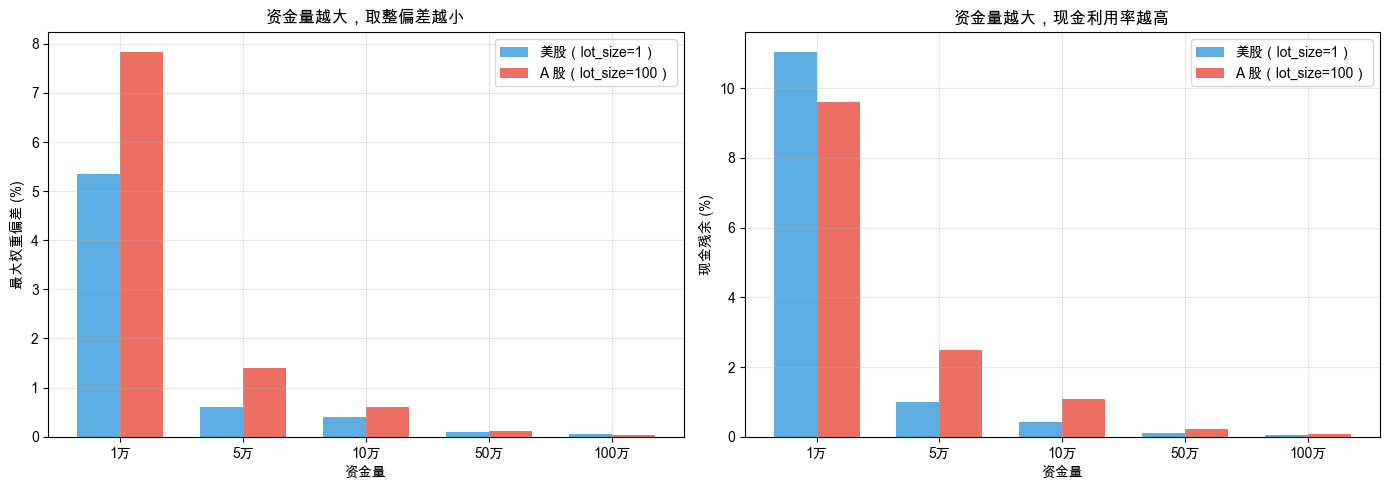


回测的世界里，权重可以精确到小数点后 N 位。
现实中只能买整数股——资金量越小、整手约束越大，'理想'和'现实'的差距越大。
A 股的 100 股整手约束让这个问题更加突出，但因为 A 股 ETF 单价低（几元钱），偏差主要来自整手约束而非单价。

订单有了，但按什么价格下单？——这是下一步的问题。


In [5]:
from oxq.trade import generate_orders, PlannedOrder
from oxq.core.types import Position
from decimal import Decimal
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ── 常量 ──
SYMBOLS = ("SPY", "QQQ", "GLD")
SYMBOL_NAMES = {"SPY": "标普500ETF", "QQQ": "纳指100ETF", "GLD": "黄金ETF"}
TARGET_WEIGHTS = {
    "SPY": Decimal("0.35"),
    "QQQ": Decimal("0.25"),
    "GLD": Decimal("0.40"),
}

# 模拟当前价格（昨日收盘价）
PRICES = {
    "SPY": Decimal("593.12"),
    "QQQ": Decimal("512.30"),
    "GLD": Decimal("298.50"),
}

# ══════════════════════════════════════════════
# 第一步：从空仓开始，10 万美元，生成订单
# ══════════════════════════════════════════════
CAPITAL = Decimal("100000")

orders = generate_orders(
    target_weights=TARGET_WEIGHTS,
    positions={},
    prices=PRICES,
    total_capital=CAPITAL,
    lot_size=1,
)

print("目标权重 → 具体订单（$100,000 美股，lot_size=1）")
print("=" * 90)
print(f"{'标的':<6} {'方向':<6} {'目标股数':>8} {'预估金额':>12} {'目标权重':>8} {'实际权重':>8} {'偏差':>8}")
print("-" * 90)

total_invested = Decimal("0")
for po in orders:
    actual_amount = po.target_shares * PRICES[po.order.symbol]
    actual_weight = actual_amount / CAPITAL
    deviation = actual_weight - po.target_weight
    total_invested += actual_amount
    print(f"{po.order.symbol:<6} {po.order.side:<6} {po.target_shares:>8} "
          f"${float(actual_amount):>10,.2f} {float(po.target_weight):>7.1%} "
          f"{float(actual_weight):>7.1%} {float(deviation):>+7.2%}")

cash_remaining = CAPITAL - total_invested
print(f"\n投入金额：${float(total_invested):,.2f}")
print(f"剩余现金：${float(cash_remaining):,.2f}（{float(cash_remaining / CAPITAL):.2%} 的资金没有被使用）")

# ══════════════════════════════════════════════
# 第二步：美股 vs A 股取整对比
# ══════════════════════════════════════════════
# A 股用真实 ETF 价格（单位：元）
A_SYMBOL_NAMES = {"510300": "沪深300ETF", "513100": "纳指100ETF", "518880": "黄金ETF"}
A_SYMBOLS = ("510300", "513100", "518880")
A_PRICES = {
    "510300": Decimal("4.27"),    # 沪深300ETF
    "513100": Decimal("1.72"),    # 纳指100ETF
    "518880": Decimal("8.04"),    # 黄金ETF
}
A_CAPITAL = Decimal("100000")  # 10 万人民币
A_WEIGHTS = {
    "510300": Decimal("0.35"),
    "513100": Decimal("0.25"),
    "518880": Decimal("0.40"),
}

orders_us = generate_orders(
    target_weights=TARGET_WEIGHTS, positions={}, prices=PRICES,
    total_capital=CAPITAL, lot_size=1,
)
orders_cn = generate_orders(
    target_weights=A_WEIGHTS, positions={}, prices=A_PRICES,
    total_capital=A_CAPITAL, lot_size=100,
)

us_map = {po.order.symbol: po for po in orders_us}
cn_map = {po.order.symbol: po for po in orders_cn}

print("\n\n美股 $100,000（lot_size=1）vs A 股 ¥100,000（lot_size=100）取整偏差对比")
print("=" * 100)
print(f"{'目标权重':>8} │ {'美股标的':<6} {'股数':>6} {'实际权重':>8} {'偏差':>8} │ "
      f"{'A股标的':<10} {'股数':>6} {'实际权重':>8} {'偏差':>8}")
print("-" * 100)

for us_sym, cn_sym in zip(SYMBOLS, A_SYMBOLS):
    tw = float(TARGET_WEIGHTS[us_sym])
    # 美股
    us = us_map[us_sym]
    us_actual = float(us.target_shares * PRICES[us_sym] / CAPITAL)
    us_dev = us_actual - tw
    # A 股（可能缺失）
    if cn_sym in cn_map:
        cn = cn_map[cn_sym]
        cn_actual = float(cn.target_shares * A_PRICES[cn_sym] / A_CAPITAL)
        cn_dev = cn_actual - tw
        cn_shares = cn.target_shares
    else:
        cn_actual = 0.0
        cn_dev = -tw
        cn_shares = 0
    print(f"{tw:>7.1%} │ {us_sym:<6} {us.target_shares:>6} {us_actual:>7.1%} {us_dev:>+7.2%} │ "
          f"{A_SYMBOL_NAMES[cn_sym]:<10} {cn_shares:>6} {cn_actual:>7.1%} {cn_dev:>+7.2%}")

# A 股汇总
us_total = sum(us_map[s].target_shares * PRICES[s] for s in SYMBOLS)
cn_total = sum(cn_map[s].target_shares * A_PRICES[s] for s in A_SYMBOLS if s in cn_map)
print(f"\n美股现金残余：${float(CAPITAL - us_total):,.2f}（{float((CAPITAL - us_total) / CAPITAL):.2%}）")
print(f"A 股现金残余：¥{float(A_CAPITAL - cn_total):,.2f}（{float((A_CAPITAL - cn_total) / A_CAPITAL):.2%}）")

# ══════════════════════════════════════════════
# 第三步：资金量对取整偏差的影响（美股 vs A 股对比）
# ══════════════════════════════════════════════
# 统一资金档位：1万、5万、10万、50万、100万
COMMON_CAPITALS = [10_000, 50_000, 100_000, 500_000, 1_000_000]

def calc_deviations(capitals, weights, prices, lot_size):
    """计算各资金量下的最大偏差和现金残余。"""
    results = []
    for cap in capitals:
        cap_d = Decimal(str(cap))
        ords = generate_orders(
            target_weights=weights, positions={}, prices=prices,
            total_capital=cap_d, lot_size=lot_size,
        )
        devs = {}
        total_inv = Decimal("0")
        ord_map = {po.order.symbol: po for po in ords}
        for sym in weights:
            if sym in ord_map:
                actual = ord_map[sym].target_shares * prices[sym]
                devs[sym] = float(actual / cap_d - weights[sym])
                total_inv += actual
            else:
                devs[sym] = float(-weights[sym])
        cash = cap_d - total_inv
        results.append({
            "capital": cap,
            "max_dev": max(abs(v) for v in devs.values()) if devs else 0,
            "cash_pct": float(cash / cap_d),
            "devs": devs,
        })
    return results

us_data = calc_deviations(COMMON_CAPITALS, TARGET_WEIGHTS, PRICES, lot_size=1)
cn_data = calc_deviations(COMMON_CAPITALS, A_WEIGHTS, A_PRICES, lot_size=100)

# ── 打印美股表格 ──
print("\n\n资金量 vs 取整偏差（美股 lot_size=1）")
print("=" * 70)
print(f"{'资金量':>12} {'SPY偏差':>10} {'QQQ偏差':>10} {'GLD偏差':>10} {'现金残余':>10} {'残余占比':>8}")
print("-" * 70)
for d in us_data:
    cap = d["capital"]
    devs = d["devs"]
    cash_pct = d["cash_pct"]
    cash_val = cap * cash_pct
    print(f"${cap:>11,} {devs.get('SPY', 0):>+9.2%} {devs.get('QQQ', 0):>+9.2%} "
          f"{devs.get('GLD', 0):>+9.2%} ${cash_val:>8,.2f} {cash_pct:>7.2%}")

# ── 打印 A 股表格 ──
print(f"\n资金量 vs 取整偏差（A 股 lot_size=100）")
print("=" * 80)
print(f"{'资金量':>12} {'沪深300偏差':>12} {'纳指100偏差':>12} {'黄金偏差':>10} {'现金残余':>12} {'残余占比':>8}")
print("-" * 80)
for d in cn_data:
    cap = d["capital"]
    devs = d["devs"]
    cash_pct = d["cash_pct"]
    cash_val = cap * cash_pct
    print(f"¥{cap:>11,} {devs.get('510300', 0):>+11.2%} {devs.get('513100', 0):>+11.2%} "
          f"{devs.get('518880', 0):>+9.2%} ¥{cash_val:>10,.2f} {cash_pct:>7.2%}")

# ── 可视化：美股 vs A 股并排对比 ──
bar_width = 0.35

us_max_devs = [d["max_dev"] * 100 for d in us_data]
cn_max_devs = [d["max_dev"] * 100 for d in cn_data]
us_cash_pcts = [d["cash_pct"] * 100 for d in us_data]
cn_cash_pcts = [d["cash_pct"] * 100 for d in cn_data]

x = np.arange(len(COMMON_CAPITALS))
labels = [f"{c//10000}万" for c in COMMON_CAPITALS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：最大权重偏差
ax1.bar(x - bar_width/2, us_max_devs, bar_width, label='美股（lot_size=1）',
        color='#3498DB', alpha=0.8)
ax1.bar(x + bar_width/2, cn_max_devs, bar_width, label='A 股（lot_size=100）',
        color='#E74C3C', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('资金量')
ax1.set_ylabel('最大权重偏差 (%)')
ax1.set_title('资金量越大，取整偏差越小')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：现金残余
ax2.bar(x - bar_width/2, us_cash_pcts, bar_width, label='美股（lot_size=1）',
        color='#3498DB', alpha=0.8)
ax2.bar(x + bar_width/2, cn_cash_pcts, bar_width, label='A 股（lot_size=100）',
        color='#E74C3C', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_xlabel('资金量')
ax2.set_ylabel('现金残余 (%)')
ax2.set_title('资金量越大，现金利用率越高')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n回测的世界里，权重可以精确到小数点后 N 位。")
print("现实中只能买整数股——资金量越小、整手约束越大，'理想'和'现实'的差距越大。")
print("A 股的 100 股整手约束让这个问题更加突出，但因为 A 股 ETF 单价低（几元钱），偏差主要来自整手约束而非单价。")
print("\n订单有了，但按什么价格下单？——这是下一步的问题。")

### Step 1 解读

第一次看到"理想"和"现实"的差距。

回测引擎在内部用浮点数精确分配权重——SPY 就是精确的 35.000%。但你去下单时，只能买整数股。59 股 SPY 的实际权重可能是 34.99%，不是 35.00%。

美股的差距很小（lot_size=1），但 A 股的 100 股整手约束让偏差成倍放大。小资金账户（比如 10 万人民币做三只 ETF 的风险平价）可能连基本的权重分布都无法实现。

**取整偏差是系统性的**——每次调仓都会产生，日积月累就是真实的收益偏差。

还有一笔"隐形损失"：现金残余。那些因为凑不成整股而趴在账户里的现金，一分钱收益都没产生。

但这只是第一个问题。订单生成了，按什么价格下单？

---

## Step 2: 价格变了怎么办

Step 1 生成了订单清单——"买 SPY 59 股，按 $593.12"。但 $593.12 是昨天的收盘价。你现在下单，SPY 可能已经涨到 $596 了，也可能跌到 $590。

按哪个价格买？这个差异有多大影响？

👉 **打开 `specs/spec-02-fill-price.md`，复制到 TRAE。**

数据加载完成
  标普500ETF(SPY): 1301 个交易日
  纳指100ETF(QQQ): 1301 个交易日
  黄金ETF(GLD): 1301 个交易日

四种成交价模式对比（含佣金）
成交价模式                     累计收益率      年化收益率       最大回撤       夏普比率       交易次数
----------------------------------------------------------------------------------------
收盘价（回测理想）               118.85%     15.18%    -22.50%       1.24        181
次日开盘价（最接近实盘）            118.10%     15.12%    -22.63%       1.23        181
次日最高价（最差买入）             114.13%     14.76%    -23.56%       1.21        183
次日最低价（最好买入）             116.77%     15.00%    -22.87%       1.22        182


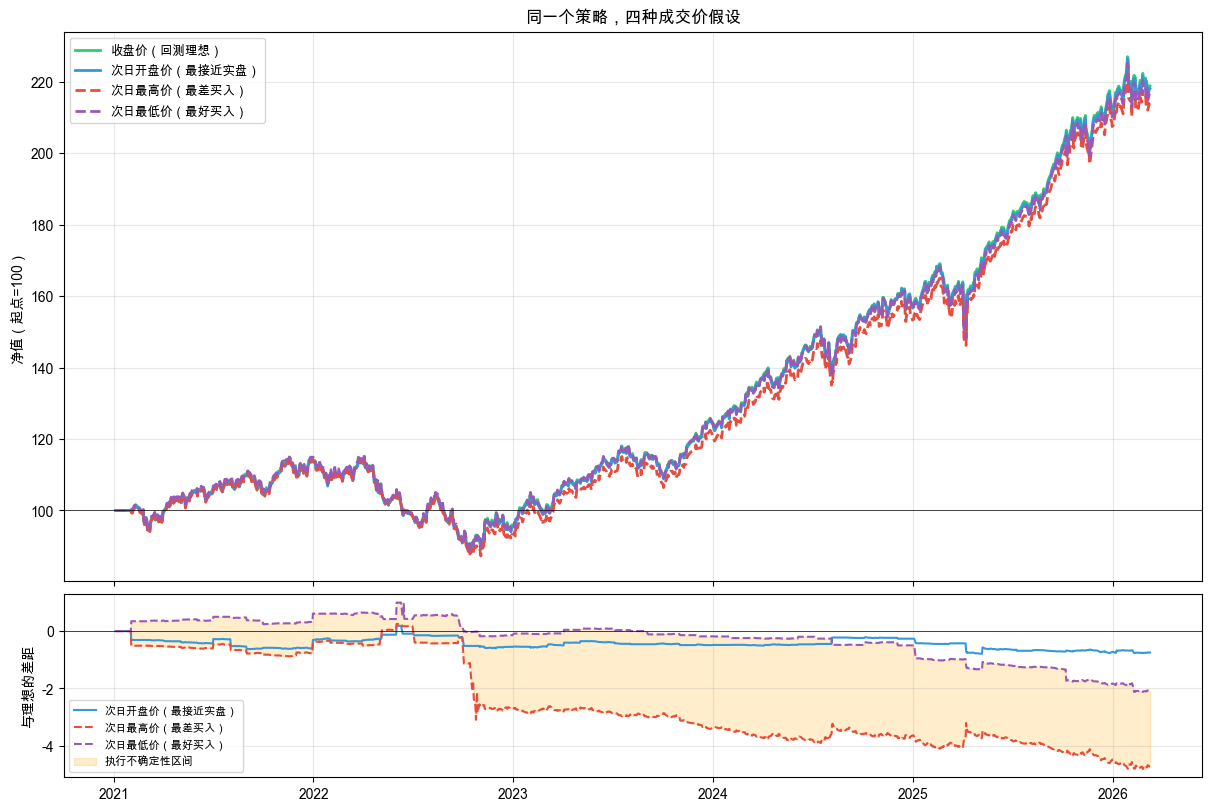


收盘价（回测理想）：118.85%
次日开盘价（最接近实盘）：118.10%，比理想少了 0.75%
次日最高价（最差情况）：114.13%，比理想少了 4.72%
次日最低价（最好情况）：116.77%，比理想少了 2.08%

最好和最差之间的差距：2.64%
这个带状区域就是你无法控制的'执行不确定性'。


成本层叠分析（次日开盘价模式）

成本层级                          累计收益率      年化收益率       夏普比率
------------------------------------------------------------
无成本                         120.29%     15.31%       1.24
+ 佣金（万一）                    118.10%     15.12%       1.23
+ 佣金 + 滑点（0.1%）             115.64%     14.90%       1.21


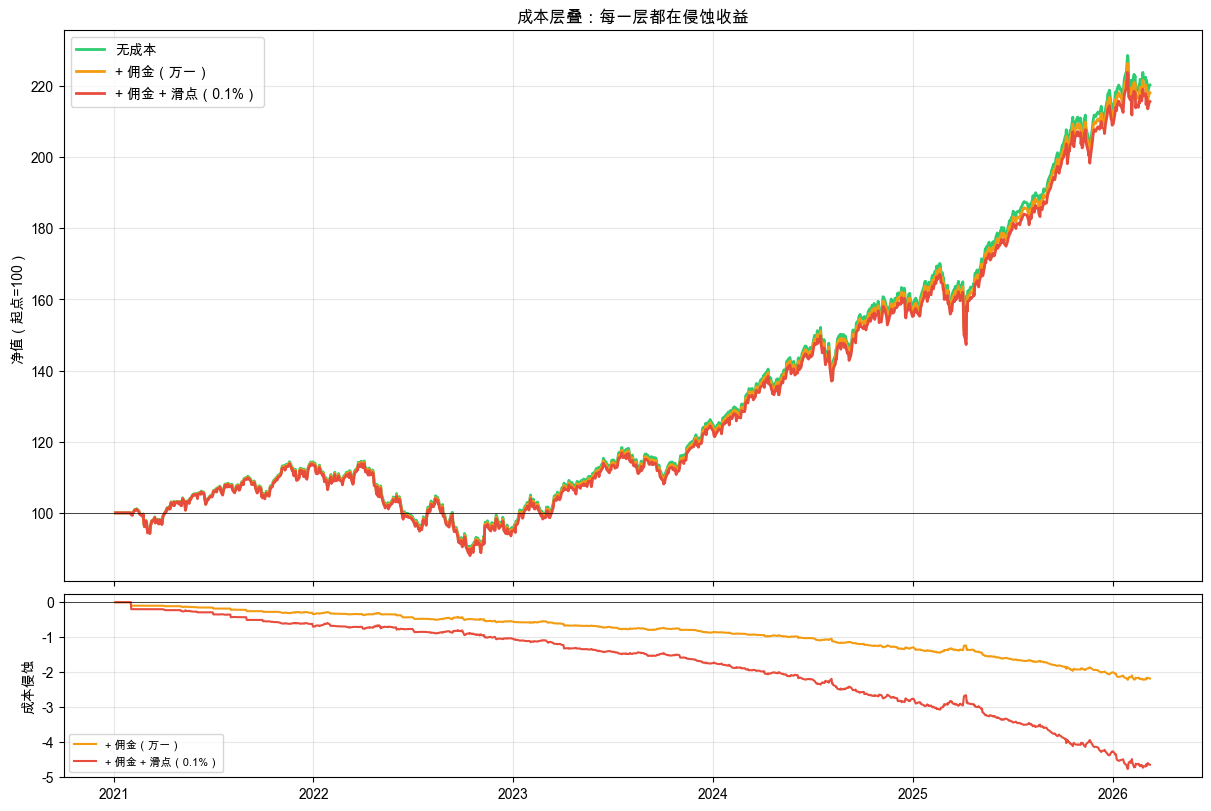


成本侵蚀总计：4.65%
  其中佣金：2.18%
  其中滑点：2.46%

A 股的情况更严重：卖出还要额外交 0.05% 的印花税。
如果你的策略年化收益只有 5%，交易成本可能吃掉其中的 1-2%。

成本的影响清楚了。但这些都是'估算'——真实执行到底差多少？下一步揭晓。


In [6]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility
from oxq.signals import RiskParity
from oxq.rules import RebalanceRule, StopLossRule
from oxq.trade import SimBroker, FillPriceMode, PercentageFee, PercentageSlippage
from oxq.universe import StaticUniverse
import numpy as np

# ── 下载数据（已有本地缓存则跳过失败） ──
START = "2021-01-01"
today = pd.Timestamp.now().strftime("%Y-%m-%d")

downloader = YFinanceDownloader()
for sym in SYMBOLS:
    try:
        downloader.download(sym, start=START, end=today)
    except Exception as e:
        print(f"  {sym} 下载失败（{e}），使用本地缓存")

print("数据加载完成")
market = LocalMarketDataProvider()
for sym in SYMBOLS:
    bars = market.get_bars(sym, START, today)
    print(f"  {SYMBOL_NAMES[sym]}({sym}): {len(bars)} 个交易日")

# ── 策略定义（与 Q4 相同的风险平价 + 止损） ──
universe = StaticUniverse(symbols=SYMBOLS, name="us-macro-etf")
BEST_FREQ = 21  # 每月调仓
BEST_SL = 0.10   # 10% 止损

COMMON = dict(
    universe=universe,
    indicators={"vol": (RollingVolatility(), {"column": "close", "period": 20})},
    signals={"tw": (RiskParity(), {"vol": "vol"})},
    entry_rules=[],
    exit_rules=[],
)

def make_strategy(name):
    return Strategy(
        name=name,
        rebalance_rules=[RebalanceRule(weight_col="tw", frequency=BEST_FREQ)],
        order_rules=[StopLossRule(threshold=BEST_SL)],
        **COMMON,
    )

# ══════════════════════════════════════════════
# 四种成交价模式压力测试
# ══════════════════════════════════════════════
MODE_NAMES = {
    FillPriceMode.CLOSE: "收盘价（回测理想）",
    FillPriceMode.NEXT_OPEN: "次日开盘价（最接近实盘）",
    FillPriceMode.NEXT_HIGH: "次日最高价（最差买入）",
    FillPriceMode.NEXT_LOW: "次日最低价（最好买入）",
}

FEE_MODEL = PercentageFee(rate=Decimal("0.001"), min_fee=Decimal("1"))

results_mode = {}
for mode in FillPriceMode:
    broker = SimBroker(fee_model=FEE_MODEL, fill_price_mode=mode)
    result = Engine().run(
        make_strategy(f"mode-{mode.value}"),
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=today,
    )
    results_mode[mode] = result

# ── 对比表 ──
print("\n四种成交价模式对比（含佣金）")
print("=" * 88)
print(f"{'成交价模式':<20} {'累计收益率':>10} {'年化收益率':>10} {'最大回撤':>10} {'夏普比率':>10} {'交易次数':>10}")
print("-" * 88)
for mode in FillPriceMode:
    r = results_mode[mode]
    print(f"{MODE_NAMES[mode]:<20} {r.total_return():>10.2%} {r.annualized_return():>10.2%} "
          f"{r.max_drawdown():>10.2%} {r.sharpe_ratio():>10.2f} {len(r.trades):>10}")

# ── 获取公共交易日 ──
mktdata = {}
for sym in SYMBOLS:
    mktdata[sym] = market.get_bars(sym, START, today)
common_days = mktdata[SYMBOLS[0]].index
for sym in SYMBOLS[1:]:
    common_days = common_days.intersection(mktdata[sym].index)

# ── 净值曲线 + 差距子图 ──
mode_colors = {
    FillPriceMode.CLOSE: '#2ECC71',
    FillPriceMode.NEXT_OPEN: '#3498DB',
    FillPriceMode.NEXT_HIGH: '#E74C3C',
    FillPriceMode.NEXT_LOW: '#9B59B6',
}
mode_styles = {
    FillPriceMode.CLOSE: '-',
    FillPriceMode.NEXT_OPEN: '-',
    FillPriceMode.NEXT_HIGH: '--',
    FillPriceMode.NEXT_LOW: '--',
}

# 准备归一化数据
norm_curves = {}
for mode in FillPriceMode:
    equity = pd.Series(dict(results_mode[mode].equity_curve))
    equity = equity.reindex(common_days).dropna()
    norm_curves[mode] = equity / equity.iloc[0] * 100

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1],
                                      sharex=True, layout='constrained')

# 上图：净值曲线
for mode in FillPriceMode:
    ax_top.plot(norm_curves[mode].index, norm_curves[mode].values, label=MODE_NAMES[mode],
                color=mode_colors[mode], linestyle=mode_styles[mode], linewidth=2)

ax_top.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax_top.set_ylabel('净值（起点=100）')
ax_top.set_title('同一个策略，四种成交价假设')
ax_top.legend(loc='upper left', fontsize=9)
ax_top.grid(True, alpha=0.3)

# 下图：与收盘价基准的差距 + HIGH/LOW 之间填充执行不确定性区间
baseline = norm_curves[FillPriceMode.CLOSE]
diff_curves = {}
for mode in FillPriceMode:
    if mode == FillPriceMode.CLOSE:
        continue
    diff_curves[mode] = (norm_curves[mode] - baseline).dropna()
    ax_bot.plot(diff_curves[mode].index, diff_curves[mode].values, label=MODE_NAMES[mode],
                color=mode_colors[mode], linestyle=mode_styles[mode], linewidth=1.5)

# 在下图填充 HIGH 和 LOW 的差距区间
diff_high = diff_curves[FillPriceMode.NEXT_HIGH]
diff_low = diff_curves[FillPriceMode.NEXT_LOW]
common_diff_idx = diff_high.index.intersection(diff_low.index)
ax_bot.fill_between(common_diff_idx,
                     diff_high.reindex(common_diff_idx),
                     diff_low.reindex(common_diff_idx),
                     alpha=0.2, color='orange', label='执行不确定性区间')

ax_bot.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax_bot.set_ylabel('与理想的差距')
ax_bot.legend(loc='lower left', fontsize=8)
ax_bot.grid(True, alpha=0.3)

plt.show()

# ── 分析 ──
ret_close = results_mode[FillPriceMode.CLOSE].total_return()
ret_open = results_mode[FillPriceMode.NEXT_OPEN].total_return()
ret_high = results_mode[FillPriceMode.NEXT_HIGH].total_return()
ret_low = results_mode[FillPriceMode.NEXT_LOW].total_return()

def diff_desc(ret, baseline, label):
    diff = ret - baseline
    if diff >= 0:
        return f"{label}：{ret:.2%}，比理想多了 {diff:.2%}"
    else:
        return f"{label}：{ret:.2%}，比理想少了 {-diff:.2%}"

print(f"\n收盘价（回测理想）：{ret_close:.2%}")
print(diff_desc(ret_open, ret_close, "次日开盘价（最接近实盘）"))
print(diff_desc(ret_high, ret_close, "次日最高价（最差情况）"))
print(diff_desc(ret_low, ret_close, "次日最低价（最好情况）"))
print(f"\n最好和最差之间的差距：{abs(ret_low - ret_high):.2%}")
print(f"这个带状区域就是你无法控制的'执行不确定性'。")

# ══════════════════════════════════════════════
# 成本层叠：无成本 → 加佣金 → 加佣金+滑点
# ══════════════════════════════════════════════
print("\n\n成本层叠分析（次日开盘价模式）")
print("=" * 72)

# 无成本
broker_no_cost = SimBroker(fill_price_mode=FillPriceMode.NEXT_OPEN)
r_no_cost = Engine().run(make_strategy("no-cost"), market=LocalMarketDataProvider(),
                         broker=broker_no_cost, start=START, end=today)

# 加佣金
broker_fee = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)
r_fee = Engine().run(make_strategy("fee-only"), market=LocalMarketDataProvider(),
                     broker=broker_fee, start=START, end=today)

# 加佣金 + 滑点
SLIPPAGE = PercentageSlippage(rate=Decimal("0.001"))
broker_full = SimBroker(fee_model=FEE_MODEL, slippage_model=SLIPPAGE,
                        fill_price_mode=FillPriceMode.NEXT_OPEN)
r_full = Engine().run(make_strategy("full-cost"), market=LocalMarketDataProvider(),
                      broker=broker_full, start=START, end=today)

cost_layers = [
    ("无成本", r_no_cost),
    ("+ 佣金（万一）", r_fee),
    ("+ 佣金 + 滑点（0.1%）", r_full),
]

print(f"\n{'成本层级':<24} {'累计收益率':>10} {'年化收益率':>10} {'夏普比率':>10}")
print("-" * 60)
for name, r in cost_layers:
    print(f"{name:<24} {r.total_return():>10.2%} {r.annualized_return():>10.2%} {r.sharpe_ratio():>10.2f}")

# ── 成本侵蚀：净值 + 差距子图 ──
layer_colors = ['#2ECC71', '#F39C12', '#E74C3C']

norm_layers = {}
for i, (name, r) in enumerate(cost_layers):
    equity = pd.Series(dict(r.equity_curve)).reindex(common_days).dropna()
    norm_layers[name] = equity / equity.iloc[0] * 100

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1],
                                      sharex=True, layout='constrained')

# 上图：净值曲线
for i, (name, _) in enumerate(cost_layers):
    ax_top.plot(norm_layers[name].index, norm_layers[name].values,
                label=name, color=layer_colors[i], linewidth=2)

ax_top.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax_top.set_ylabel('净值（起点=100）')
ax_top.set_title('成本层叠：每一层都在侵蚀收益')
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# 下图：与无成本基准的差距
baseline_cost = norm_layers["无成本"]
for i, (name, _) in enumerate(cost_layers):
    if name == "无成本":
        continue
    diff = norm_layers[name] - baseline_cost
    ax_bot.plot(diff.index, diff.values, label=name, color=layer_colors[i], linewidth=1.5)

ax_bot.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax_bot.set_ylabel('成本侵蚀')
ax_bot.legend(loc='lower left', fontsize=8)
ax_bot.grid(True, alpha=0.3)

plt.show()

total_erosion = r_no_cost.total_return() - r_full.total_return()
fee_erosion = r_no_cost.total_return() - r_fee.total_return()
slip_erosion = r_fee.total_return() - r_full.total_return()

print(f"\n成本侵蚀总计：{total_erosion:.2%}")
print(f"  其中佣金：{fee_erosion:.2%}")
print(f"  其中滑点：{slip_erosion:.2%}")
print(f"\nA 股的情况更严重：卖出还要额外交 0.05% 的印花税。")
print(f"如果你的策略年化收益只有 5%，交易成本可能吃掉其中的 1-2%。")
print(f"\n成本的影响清楚了。但这些都是'估算'——真实执行到底差多少？下一步揭晓。")

### Step 2 解读

四条净值曲线讲了两件事。

**第一，回测的收盘价假设是最乐观的。** 回测默认你能在收盘价精确成交——但实际上你不可能在收盘的那一瞬间下单。次日开盘价是更现实的假设，而你的实际成交价会落在次日最低价和最高价之间的某个位置。

HIGH 和 LOW 之间的带状区域就是"执行不确定性"——**同一个策略决策，仅仅因为执行时机不同，结果就有这么大的差距。** 这个差距不是策略的问题，而是执行的问题。

**第二，成本是持续的侵蚀。** 佣金和滑点不是一次性的损失，而是每次交易都在发生。一年几十次调仓下来，成本层层叠加，侵蚀掉的收益可能比你想象的多得多。

A 股的情况更严重：除了佣金和滑点，卖出时还要交 0.05% 的印花税。如果你的策略年化收益只有 5%，交易成本可能吃掉其中的 1-2%——这就是为什么低频策略往往比高频策略更适合个人投资者。

但以上都是"估算"——用不同的成交价模式模拟出来的。真实执行到底差多少？

---

## Step 3: 回测 vs 实盘，差距有多大

前两步用模拟的方式暴露了取整偏差、滑点和成本。但这些都是"估算"。

现在，我们让策略接入 Alpaca 模拟交易平台，真正跑一遍。然后把回测净值和模拟实盘净值画在同一张图上——差距一目了然。

**关键概念：** Engine 和 Strategy 完全不变，只是把数据源和交易接口换了。回测用 SimBroker + LocalMarketDataProvider，实盘用 AlpacaClient + AlpacaMarketDataProvider。策略逻辑一行都不用改。

👉 **打开 `specs/spec-03-alpaca-paper.md`，复制到 TRAE。**

> 本步需要 Alpaca 账号。如果你还没有，可以在 [alpaca.markets](https://alpaca.markets) 免费注册，选择 Paper Trading 模式。注册后在环境变量中设置：
> ```
> export ALPACA_API_KEY="你的API Key"
> export ALPACA_SECRET_KEY="你的Secret Key"
> ```

SimBroker 回测完成：累计收益 118.85%，181 笔交易

Alpaca 账户状态：ACTIVE
账户权益：$99,988.62
  SPY: 1302 个交易日
  QQQ: 1302 个交易日
  GLD: 1302 个交易日

Alpaca 数据 + SimBroker 回测：累计收益 113.20%，187 笔交易


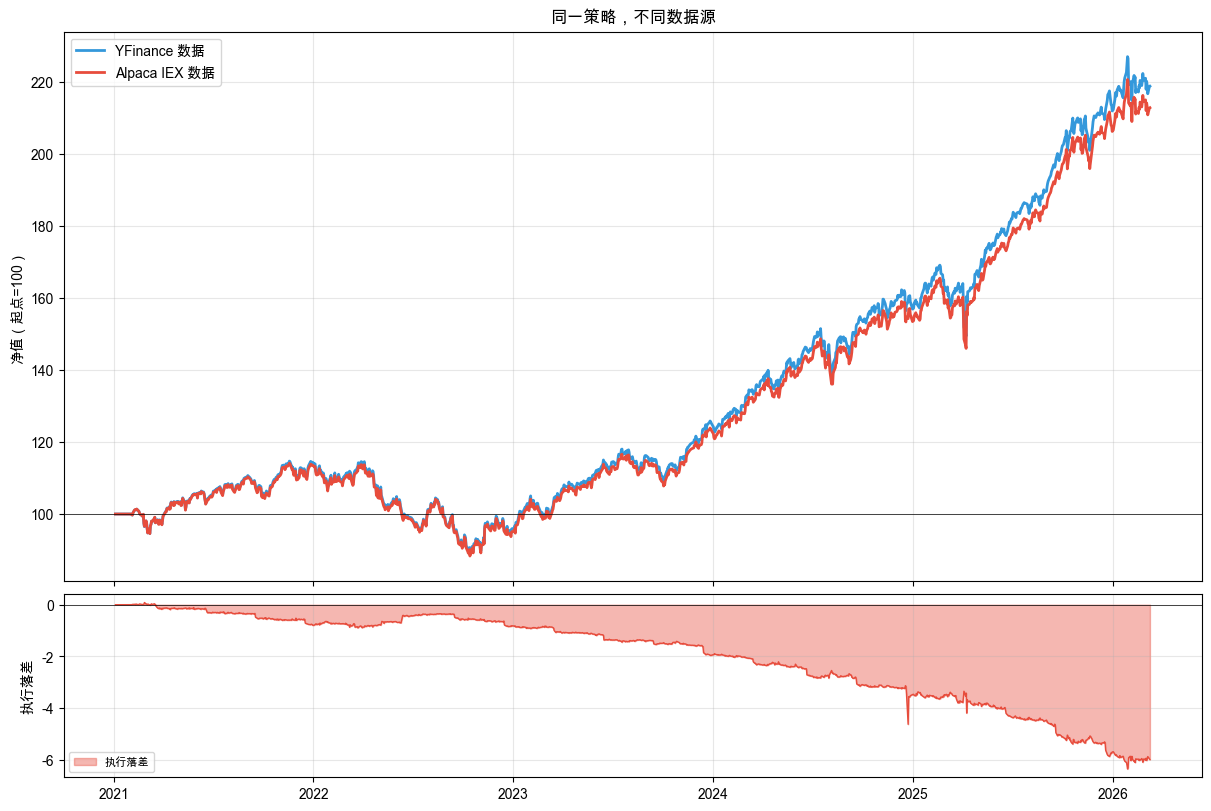


YFinance 回测：118.85%
Alpaca IEX 回测：113.20%
数据源差异：5.65%
同一个策略、同一个 SimBroker，仅仅因为数据来源不同，结果就不一样。

LiveBroker 实盘演示：提交真实订单到 Alpaca 模拟盘

当前持仓：4 个标的
  AAPL: 54 股 @ $261.61
  GLD: 83 股 @ $475.28
  QQQ: 41 股 @ $609.77
  SPY: 51 股 @ $678.05

账户权益：$99,988.62
  SPY 最新价：$677.90
  QQQ 最新价：$610.43
  GLD 最新价：$475.18

调仓计划（2 笔订单）：
标的     方向         股数         预估金额
------------------------------------
GLD    BUY         1 $    475.18
QQQ    SELL        1 $    610.43

  订单已提交：GLD BUY 1 股 → ID: bb7973ac...

  订单已提交：QQQ SELL 1 股 → ID: b828d71b...

等待成交回报...

收到 2 笔成交：
标的     方向         股数        成交价        回测价       滑点
----------------------------------------------------
GLD    BUY         1 $   475.29 $   475.18  +0.02%
QQQ    SELL        1 $   610.05 $   610.43  -0.06%

最终持仓：
  AAPL: 54 股 @ $261.61
  GLD: 84 股 @ $475.28
  QQQ: 40 股 @ $609.77
  SPY: 51 股 @ $678.05


In [ ]:
import os
import time

# ══════════════════════════════════════════════
# Part A：SimBroker 回测（基准线）
# ══════════════════════════════════════════════
# 用收盘价模式跑一次完整回测，作为"理想基准"
broker_sim = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.CLOSE)
result_sim = Engine().run(
    make_strategy("sim-baseline"),
    market=LocalMarketDataProvider(),
    broker=broker_sim,
    start=START,
    end=today,
)
print(f"SimBroker 回测完成：累计收益 {result_sim.total_return():.2%}，{len(result_sim.trades)} 笔交易")

# ══════════════════════════════════════════════
# Part B：Alpaca 模拟盘
# ══════════════════════════════════════════════
HAS_ALPACA = bool(os.environ.get("ALPACA_API_KEY"))
ALPACA_OK = False

def plot_sim_vs_live(norm_sim, norm_live, title, label_sim, label_live):
    """上下两图：上面净值曲线，下面执行落差放大。"""
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1],
                                          sharex=True, layout='constrained')
    ax_top.plot(norm_sim.index, norm_sim.values, label=label_sim, color='#3498DB', linewidth=2)
    ax_top.plot(norm_live.index, norm_live.values, label=label_live, color='#E74C3C', linewidth=2)
    ax_top.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
    ax_top.set_ylabel('净值（起点=100）')
    ax_top.set_title(title)
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    gap = norm_live - norm_sim
    ax_bot.fill_between(gap.index, 0, gap.values, alpha=0.4, color='#E74C3C', label='执行落差')
    ax_bot.plot(gap.index, gap.values, color='#E74C3C', linewidth=1)
    ax_bot.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax_bot.set_ylabel('执行落差')
    ax_bot.legend(loc='lower left', fontsize=8)
    ax_bot.grid(True, alpha=0.3)

    plt.show()

if HAS_ALPACA:
    try:
        from oxq.contrib.alpaca import AlpacaClient, AlpacaMarketDataProvider
        from oxq.trade import LiveBroker

        # 初始化 Alpaca（默认 feed="iex"，免费账户可用）
        client = AlpacaClient(paper=True)
        alpaca_market = AlpacaMarketDataProvider()

        account = client.get_account()
        print(f"\nAlpaca 账户状态：{account.get('status')}")
        print(f"账户权益：${float(account.get('equity', 0)):,.2f}")

        # ── Part B-1：历史对比（Alpaca 数据 + SimBroker） ──
        # 同一个策略，换数据源跑回测，看数据差异带来的结果差异
        alpaca_bars = alpaca_market.get_bars_multi(list(SYMBOLS), start=START, end=today)
        for sym in SYMBOLS:
            print(f"  {sym}: {len(alpaca_bars[sym])} 个交易日")

        engine_alpaca = Engine()
        engine_alpaca.setup(
            make_strategy("alpaca-data"),
            market=alpaca_market,
            broker=SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.CLOSE),
            start=START,
            end=today,
        )
        for date in engine_alpaca.dates:
            engine_alpaca.step(date)
        result_alpaca = engine_alpaca.result
        print(f"\nAlpaca 数据 + SimBroker 回测：累计收益 {result_alpaca.total_return():.2%}，"
              f"{len(result_alpaca.trades)} 笔交易")

        # 净值曲线对比
        eq_sim = pd.Series(dict(result_sim.equity_curve))
        eq_alpaca = pd.Series(dict(result_alpaca.equity_curve))
        common = eq_sim.index.intersection(eq_alpaca.index)
        eq_sim_c = eq_sim.reindex(common).dropna()
        eq_alpaca_c = eq_alpaca.reindex(common).dropna()
        norm_sim_plot = eq_sim_c / eq_sim_c.iloc[0] * 100
        norm_alpaca_plot = eq_alpaca_c / eq_alpaca_c.iloc[0] * 100

        plot_sim_vs_live(norm_sim_plot, norm_alpaca_plot,
                         '同一策略，不同数据源',
                         'YFinance 数据', 'Alpaca IEX 数据')

        data_gap = result_sim.total_return() - result_alpaca.total_return()
        print(f"\nYFinance 回测：{result_sim.total_return():.2%}")
        print(f"Alpaca IEX 回测：{result_alpaca.total_return():.2%}")
        print(f"数据源差异：{data_gap:.2%}")
        print(f"同一个策略、同一个 SimBroker，仅仅因为数据来源不同，结果就不一样。")

        # ── Part B-2：LiveBroker 实盘演示 ──
        # 用 LiveBroker 提交一轮真实订单到 Alpaca 模拟盘
        print(f"\n{'='*60}")
        print(f"LiveBroker 实盘演示：提交真实订单到 Alpaca 模拟盘")
        print(f"{'='*60}")

        # 获取当前持仓和最新价格
        current_positions = client.get_positions()
        pos_dict = {}
        for p in current_positions:
            pos_dict[p["symbol"]] = Position(
                symbol=p["symbol"],
                shares=int(p["qty"]),
                avg_cost=Decimal(p["avg_entry_price"]),
            )
        print(f"\n当前持仓：{len(pos_dict)} 个标的")
        for sym, pos in pos_dict.items():
            print(f"  {sym}: {pos.shares} 股 @ ${float(pos.avg_cost):.2f}")

        # 获取最新价格
        latest = alpaca_market.get_bars_multi(list(SYMBOLS), start=today, end=today)
        latest_prices = {}
        for sym in SYMBOLS:
            if sym in latest and len(latest[sym]) > 0:
                latest_prices[sym] = Decimal(str(latest[sym].iloc[-1]["close"]))
            else:
                # 如果今天没数据（非交易日），用最近的数据
                recent = alpaca_market.get_bars(sym, start="2026-03-01", end=today)
                latest_prices[sym] = Decimal(str(recent.iloc[-1]["close"]))

        equity = Decimal(account["equity"])
        print(f"\n账户权益：${float(equity):,.2f}")
        for sym in SYMBOLS:
            print(f"  {sym} 最新价：${float(latest_prices[sym]):.2f}")

        # 生成订单
        planned = generate_orders(
            target_weights=TARGET_WEIGHTS,
            positions=pos_dict,
            prices=latest_prices,
            total_capital=equity,
            lot_size=1,
        )

        if not planned:
            print("\n无需调仓，当前持仓已符合目标权重。")
        else:
            print(f"\n调仓计划（{len(planned)} 笔订单）：")
            print(f"{'标的':<6} {'方向':<6} {'股数':>6} {'预估金额':>12}")
            print("-" * 36)
            for p in planned:
                print(f"{p.order.symbol:<6} {p.order.side:<6} {p.order.shares:>6} "
                      f"${float(p.estimated_amount):>10,.2f}")

            # 用 LiveBroker 提交订单
            live_broker = LiveBroker(paper=True)
            order_ids = []
            for p in planned:
                try:
                    oid = live_broker.submit_order(p.order)
                    order_ids.append(oid)
                    print(f"\n  订单已提交：{p.order.symbol} {p.order.side} {p.order.shares} 股 → ID: {oid[:8]}...")
                except Exception as e:
                    print(f"\n  订单提交失败：{p.order.symbol} {p.order.side} → {e}")

            # 等待成交回报
            if order_ids:
                print(f"\n等待成交回报...")
                time.sleep(3)

                fills = live_broker.get_fills()
                print(f"\n收到 {len(fills)} 笔成交：")
                print(f"{'标的':<6} {'方向':<6} {'股数':>6} {'成交价':>10} {'回测价':>10} {'滑点':>8}")
                print("-" * 52)
                for f in fills:
                    # 对比回测价（最新收盘价）和实际成交价
                    backtest_price = latest_prices.get(f.order.symbol, Decimal("0"))
                    if backtest_price > 0:
                        slip = float((f.filled_price - backtest_price) / backtest_price)
                    else:
                        slip = 0.0
                    print(f"{f.order.symbol:<6} {f.order.side:<6} {f.order.shares:>6} "
                          f"${float(f.filled_price):>9.2f} ${float(backtest_price):>9.2f} {slip:>+7.2%}")

                if not fills:
                    print("  还没收到成交——可能市场已关闭，订单会在下次开盘时执行。")
                    # 查询订单状态
                    print("\n订单状态：")
                    for oid in order_ids:
                        order_info = client.get_order(oid)
                        print(f"  {order_info['symbol']} {order_info['side'].upper()} "
                              f"{order_info['qty']} 股 → {order_info['status']}")

            live_broker.close()

        # 查看最终持仓
        final_positions = client.get_positions()
        if final_positions:
            print(f"\n最终持仓：")
            for pos in final_positions:
                print(f"  {pos['symbol']}: {pos['qty']} 股 @ ${float(pos['avg_entry_price']):.2f}")

        # 用回测结果作为 result_live（后续 Step 4 需要）
        result_live = result_alpaca

        ALPACA_OK = True

    except Exception as e:
        print(f"\nAlpaca 连接失败：{e}")
        print("\n自动切换到模拟方案...")

if not HAS_ALPACA:
    print("\n未检测到 ALPACA_API_KEY 环境变量。")
    print("\n如果你有 Alpaca 账号，请设置环境变量后重新运行：")
    print("  export ALPACA_API_KEY='你的API Key'")
    print("  export ALPACA_SECRET_KEY='你的Secret Key'")

if not ALPACA_OK:
    print("\n没有 Alpaca 也没关系——我们用 Step 2 的 NEXT_OPEN 模式模拟'实盘'效果：")

    # 用 NEXT_OPEN 作为"模拟实盘"替代
    broker_pseudo_live = SimBroker(fee_model=FEE_MODEL, slippage_model=SLIPPAGE,
                                   fill_price_mode=FillPriceMode.NEXT_OPEN)
    result_live = Engine().run(
        make_strategy("pseudo-live"),
        market=LocalMarketDataProvider(),
        broker=broker_pseudo_live,
        start=START,
        end=today,
    )

    print(f"\n模拟'实盘'完成：累计收益 {result_live.total_return():.2%}，{len(result_live.trades)} 笔交易")

    eq_sim = pd.Series(dict(result_sim.equity_curve))
    eq_live = pd.Series(dict(result_live.equity_curve))
    common = eq_sim.index.intersection(eq_live.index)
    eq_sim = eq_sim.reindex(common).dropna()
    eq_live = eq_live.reindex(common).dropna()
    norm_sim_plot = eq_sim / eq_sim.iloc[0] * 100
    norm_live_plot = eq_live / eq_live.iloc[0] * 100

    plot_sim_vs_live(norm_sim_plot, norm_live_plot,
                     '回测 vs 模拟实盘（无 Alpaca 替代方案）',
                     'SimBroker 回测（收盘价）',
                     '模拟实盘（次日开盘+佣金+滑点）')

    gap = result_sim.total_return() - result_live.total_return()
    print(f"\n回测收益（理想）：{result_sim.total_return():.2%}")
    print(f"模拟实盘收益：{result_live.total_return():.2%}")
    print(f"执行落差：{gap:.2%}")
    print(f"\n这个差距就是 implementation shortfall——从'回测说能赚'到'实际赚了多少'之间的距离。")
    print(f"真实的 Alpaca 模拟盘差距可能更大或更小，但方向是一样的：实盘总是比回测差。")

### Step 3 解读

这一步做了两件事，揭示了两层执行落差。

**第一层：数据源差异。** 同一个策略、同一个 SimBroker，仅仅因为行情数据来自不同的供应商（YFinance vs Alpaca IEX），回测结果就不一样。这是因为不同数据源的收盘价可能有微小差异（四舍五入、调整方式、采样时间点不同）。你以为回测结果是"确定的"，其实连数据本身都有不确定性。

**第二层：真实执行差异。** 用 LiveBroker 向 Alpaca 模拟盘提交真实订单后，成交价和你预期的收盘价总是不一样。这就是**执行落差（implementation shortfall）**——从"策略决定买"到"真正买到"之间的距离。差距来自三个方面：

1. **成交价偏差**——回测用收盘价，实盘在某个时刻成交，价格已经变了
2. **交易成本**——佣金、印花税（A 股）
3. **市场冲击**——你的买单本身推高了价格（大资金才明显，小资金可忽略）

关键认知：**执行落差不是 bug，而是从回测到实盘必然存在的"税"。** 你需要做的不是消除它（不可能），而是：
- 知道它大概有多大（Step 2 的压力测试）
- 监控它有没有异常放大（Step 4 的执行报告）
- 在评估策略时预留这个空间（回测收益减去预估的执行落差才是合理预期）

还有一个重要的设计细节：**Engine 和 Strategy 一行都没改。** 从回测切换到模拟实盘，只是换了数据源和交易接口。这就是 open-xquant 的 provider-agnostic 架构——策略逻辑和执行环境完全解耦。

差距看到了，但具体哪笔交易差得多、哪笔差得少？

---

## Step 4: 怎么知道执行得对不对

Step 3 让你看到了整体的执行落差。但"整体差 2%"这个数字不够——你需要知道：

- 具体哪笔交易差得最多？
- 是特定标的的问题，还是特定日期的问题？
- 大部分交易的执行质量如何？

这就是**执行报告**的作用：逐笔对账，找到问题。

👉 **打开 `specs/spec-04-execution-report.md`，复制到 TRAE。**

执行报告：逐笔对比（前 20 笔）
日期           标的     方向            回测价        实盘价       滑点     回测股数     实盘股数    股数差
----------------------------------------------------------------------------------------------------
2021-02-02   GLD    BUY    $   172.11 $   172.14  +0.02%      213      211     -2
2021-03-04   GLD    BUY    $     0.00 $   159.00  +0.00%        0        3     +3
2021-04-05   GLD    BUY    $   161.92 $   161.91  -0.01%       19       21     +2
2021-05-04   GLD    SELL   $   166.58 $   166.56  -0.01%       26       30     +4
2021-06-03   GLD    BUY    $   175.27 $   175.25  -0.01%       32       31     -1
2021-07-02   GLD    SELL   $   167.29 $   167.29  +0.00%       89       79    -10
2021-08-03   GLD    BUY    $   169.49 $   169.48  -0.01%      111      107     -4
2021-09-01   GLD    SELL   $   169.70 $   169.72  +0.01%      114      119     +5
2021-10-01   GLD    BUY    $   164.59 $   164.59  -0.00%       58       61     +3
2021-11-01   GLD    SELL   $   167.52 $   167.56  +0.02%    

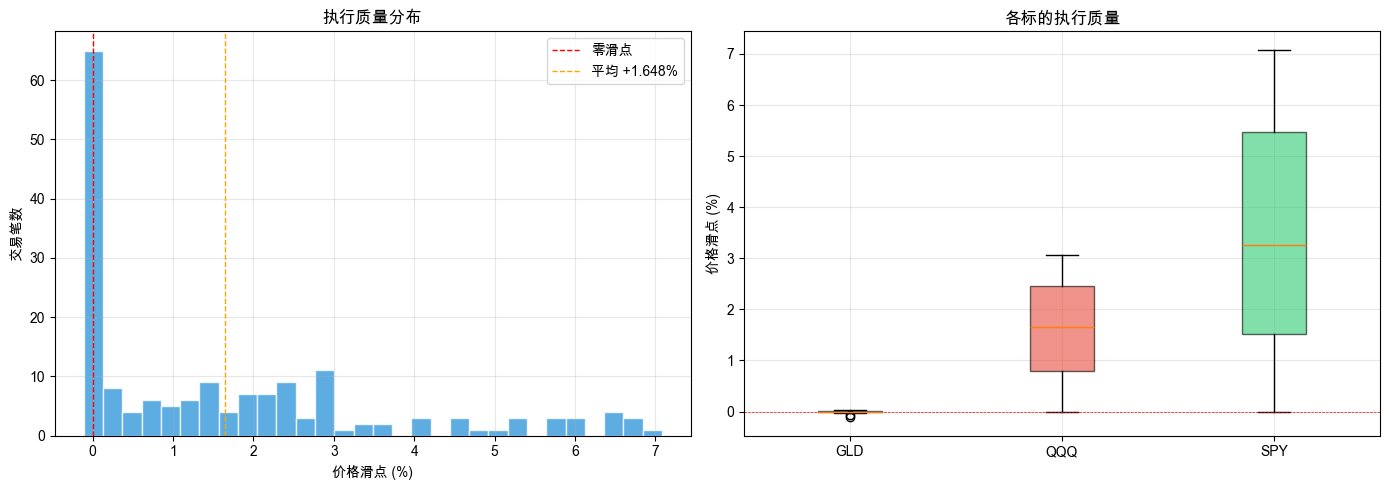


执行质量统计
总交易笔数：174
平均滑点：+1.648%
中位数滑点：+0.983%
最小滑点：-0.112%
最大滑点：+7.082%

滑点超过 0.5% 的交易：99 笔（57%）
大部分交易的执行质量正常，少数几笔偏差较大——这就是执行层面的'尾部风险'。


桥接 A 股
你在美股模拟盘上看到的所有问题，在 A 股上一模一样：

  1. 取整偏差 → A 股 100 股整手，偏差比美股大得多
  2. 价格滑点 → A 股同样存在，开盘价和收盘价经常差距很大
  3. 交易成本 → A 股还要额外付印花税（卖出 0.05%）
  4. 执行落差 → 同样的策略，A 股的执行落差可能更大

操作建议：
  - 用 A 股券商 APP 手动操作时，先用 generate_orders() 生成订单清单
  - 定期对比回测净值和实际账户净值，监控执行落差
  - 如果执行落差持续放大，检查是成本问题还是执行时机问题


In [8]:
from oxq.portfolio.execution_report import ExecutionReport

# ══════════════════════════════════════════════
# 生成执行报告：SimBroker（理想）vs 模拟实盘
# ══════════════════════════════════════════════
report = ExecutionReport(
    sim_fills=result_sim.trades,
    live_fills=result_live.trades,
)

# ── 逐笔对比表（前 20 笔） ──
comparisons = report.comparisons
print("执行报告：逐笔对比（前 20 笔）")
print("=" * 100)
print(f"{'日期':<12} {'标的':<6} {'方向':<6} {'回测价':>10} {'实盘价':>10} {'滑点':>8} {'回测股数':>8} {'实盘股数':>8} {'股数差':>6}")
print("-" * 100)
for comp in comparisons[:20]:
    print(f"{comp.date:<12} {comp.symbol:<6} {comp.side:<6} "
          f"${float(comp.sim_avg_price):>9.2f} ${float(comp.live_avg_price):>9.2f} "
          f"{float(comp.price_slippage):>+7.2%} {comp.sim_shares:>8} {comp.live_shares:>8} "
          f"{comp.shares_diff:>+6}")

# ── 汇总统计 ──
summary = report.summary()
print(f"\n汇总统计")
print("=" * 50)
print(f"总交易笔数：{summary['total_trades']}")
print(f"匹配交易：{summary['matched_trades']}（回测和实盘都有）")
print(f"仅回测有：{summary['sim_only_trades']}")
print(f"仅实盘有：{summary['live_only_trades']}")
print(f"平均价格滑点：{float(summary['avg_price_slippage']):+.4%}")
print(f"总手续费差异：${float(summary['total_fee_diff']):,.2f}")

# ══════════════════════════════════════════════
# 找出"最贵的一笔"——滑点最大的交易
# ══════════════════════════════════════════════
matched = [c for c in comparisons if c.sim_shares > 0 and c.live_shares > 0]
if matched:
    worst = max(matched, key=lambda c: abs(float(c.price_slippage)))
    print(f"\n最贵的一笔交易")
    print("=" * 50)
    print(f"日期：{worst.date}")
    print(f"标的：{worst.symbol}（{SYMBOL_NAMES.get(worst.symbol, worst.symbol)}）")
    print(f"方向：{worst.side}")
    print(f"回测成交价：${float(worst.sim_avg_price):.2f}")
    print(f"实盘成交价：${float(worst.live_avg_price):.2f}")
    print(f"价格滑点：{float(worst.price_slippage):+.4%}")

    # 分析原因
    if abs(float(worst.price_slippage)) > 0.01:
        print(f"\n滑点超过 1%——可能原因：")
        print(f"  - 当天市场波动特别大")
        print(f"  - 该标的流动性较差")
        print(f"  - 开盘价和收盘价差距大（跳空）")

# ══════════════════════════════════════════════
# 执行质量分布（滑点直方图）
# ══════════════════════════════════════════════
if matched:
    slippages = [float(c.price_slippage) * 100 for c in matched]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 左图：滑点直方图
    ax1.hist(slippages, bins=30, color='#3498DB', alpha=0.8, edgecolor='white')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=1, label='零滑点')
    ax1.axvline(x=np.mean(slippages), color='orange', linestyle='--', linewidth=1,
                label=f'平均 {np.mean(slippages):+.3f}%')
    ax1.set_xlabel('价格滑点 (%)')
    ax1.set_ylabel('交易笔数')
    ax1.set_title('执行质量分布')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 右图：按标的分组的滑点箱线图
    slip_by_symbol = {}
    for c in matched:
        sym = c.symbol
        if sym not in slip_by_symbol:
            slip_by_symbol[sym] = []
        slip_by_symbol[sym].append(float(c.price_slippage) * 100)

    symbols_sorted = sorted(slip_by_symbol.keys())
    box_data = [slip_by_symbol[s] for s in symbols_sorted]
    bp = ax2.boxplot(box_data, tick_labels=symbols_sorted, patch_artist=True)
    colors_box = ['#3498DB', '#E74C3C', '#2ECC71']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
    ax2.set_ylabel('价格滑点 (%)')
    ax2.set_title('各标的执行质量')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 统计分析 ──
    print(f"\n执行质量统计")
    print("=" * 50)
    print(f"总交易笔数：{len(matched)}")
    print(f"平均滑点：{np.mean(slippages):+.3f}%")
    print(f"中位数滑点：{np.median(slippages):+.3f}%")
    print(f"最小滑点：{min(slippages):+.3f}%")
    print(f"最大滑点：{max(slippages):+.3f}%")

    # 滑点超过 0.5% 的交易占比
    big_slip = [s for s in slippages if abs(s) > 0.5]
    print(f"\n滑点超过 0.5% 的交易：{len(big_slip)} 笔（{len(big_slip)/len(matched):.0%}）")
    print(f"大部分交易的执行质量正常，少数几笔偏差较大——这就是执行层面的'尾部风险'。")

else:
    print("\n没有匹配的交易可供对比。")

# ══════════════════════════════════════════════
# 桥接 A 股
# ══════════════════════════════════════════════
print("\n\n桥接 A 股")
print("=" * 60)
print("你在美股模拟盘上看到的所有问题，在 A 股上一模一样：")
print()
print("  1. 取整偏差 → A 股 100 股整手，偏差比美股大得多")
print("  2. 价格滑点 → A 股同样存在，开盘价和收盘价经常差距很大")
print("  3. 交易成本 → A 股还要额外付印花税（卖出 0.05%）")
print("  4. 执行落差 → 同样的策略，A 股的执行落差可能更大")
print()
print("操作建议：")
print("  - 用 A 股券商 APP 手动操作时，先用 generate_orders() 生成订单清单")
print("  - 定期对比回测净值和实际账户净值，监控执行落差")
print("  - 如果执行落差持续放大，检查是成本问题还是执行时机问题")

### Step 4 解读

执行报告是实盘运行后最重要的"对账"工具。

滑点直方图讲了一个重要的事实：**大部分交易的执行质量是正常的，滑点很小。但总有少数几笔偏差特别大。** 这就是执行层面的"尾部风险"——和策略收益的尾部风险一样，你无法消除它，但你需要知道它的存在。

箱线图按标的分组，能帮你发现：是某只 ETF 的执行质量特别差（可能流动性不够），还是所有标的都差不多？如果某只标的的滑点持续偏大，你可能需要考虑换一只流动性更好的标的，或者调整下单时机。

**实盘运行的习惯：** 每次调仓后，生成执行报告对一遍账。不是看一眼净值就完了——要逐笔检查，发现异常及时处理。这和开车一样：你不会只看速度表，还要看油量、水温、胎压。

---

## 回头看：你刚才做了什么？

四步实验，四个认知升级：

1. **权重→订单**：回测的权重是理想值，现实只能买整数股。资金量越小、整手约束越大，偏差越大。还有一笔现金趴在账户里不产生收益。

2. **成交价压力测试**：同一个策略决策，仅仅因为执行时机不同（收盘价 vs 开盘价 vs 最高/最低价），结果差距很大。回测的收盘价假设是最乐观的。

3. **回测 vs 实盘**：两条净值曲线之间的差距就是"执行落差"。这不是 bug，而是从回测到实盘必然存在的"税"。

4. **执行报告**：大部分交易执行正常，少数几笔偏差较大。实盘要养成逐笔对账的习惯。

**一个更深的认知：回测收益不等于实盘收益。** 中间隔着取整偏差、滑点、佣金、印花税。在评估策略时，回测收益减去预估的执行落差，才是你的合理预期。

---

## 本章总结

### 四步探索

```
Q6 产出：通过检验的策略，信心满满
    ↓ Step 1: 权重→订单 → 取整偏差 + 现金残余
    ↓ Step 2: 四种成交价压力测试 → 滑点 + 成本全景
    ↓ Step 3: 回测 vs 实盘 → 亲眼看到执行落差
    ↓ Step 4: 执行报告 → 逐笔对账，找到差距来源
    ↓
Q7 产出：从回测到实盘的完整闭环 + "执行有成本"的认知
```

### 本章核心认知

| 认知 | 来源 |
|------|------|
| 回测权重是理想值，实际只能买整数股 | Step 1 实验 |
| 资金量越小、整手约束越大，偏差越大 | Step 1 实验 |
| 同一个决策，执行时机不同，结果差距很大 | Step 2 实验 |
| 回测的收盘价假设是最乐观的 | Step 2 实验 |
| 交易成本（佣金+滑点+印花税）持续侵蚀收益 | Step 2 实验 |
| 回测和实盘永远有差距——执行落差 | Step 3 实验 |
| 策略逻辑和执行环境可以完全解耦 | Step 3 实验 |
| 实盘要养成逐笔对账的习惯 | Step 4 实验 |
| 大部分交易正常，少数几笔偏差大——执行的尾部风险 | Step 4 实验 |

### 带走的问题

- 策略跑起来了，怎么知道**什么时候该停、什么时候该调整**？→ Q8
- 发现问题后，怎么**系统性地改进**而不是推翻重来？→ Q8